In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b1= bd.iloc[12]

In [4]:
b1['datetime']

'2019-11-18,13:54:00.503167+00:00'

In [5]:
b1['groundTrackDeviation']

1.129086057

In [6]:
lat= literal_eval(b1['lat_stereo_g16'])
long= literal_eval(b1['lon_stereo_g16'])
alt= literal_eval(b1['alt_stereo_g16'])
energy = literal_eval(b1['energyJoules_stereo_g16'])

errorlat= 4000 #meters 
errorlong= 4000
erroralt= literal_eval(b1['residual_dist_stereo_g16'])

In [7]:
print (np.abs(lat[25]-lat[0]), np.abs(long[25]-long[0]), np.abs(alt[25]-alt[0]))

0.029455450000000383 0.02875959000000705 7.517602240000002


In [8]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom (lat1, long1, lat2, long2, r= 6371): #haversine equation?
    lat1rad = np.radians(lat1)
    long1rad = np.radians(long1)
    lat2rad = np.radians(lat2)
    long2rad = np.radians(long2)
    dlat = lat2rad - lat1rad
    dlong = long2rad - long1rad
#   for i in range(len(lat)):
#       if lat[i] == lat1:
#           errorindex= i

    a= np.sin(dlat/2)**2 + np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2
    b= 2*np.arcsin(np.sqrt(a))
    
    errorla1= -np.cos(dlat/2)**2*np.sin(dlat/2)**2-np.sin(lat1)*np.cos(lat2)*np.sin(dlong/2)**2
    errorla2= np.cos(dlat/2)**2*np.sin(dlat/2)**2-np.cos(lat1)*np.sin(lat2)*np.sin(dlong/2**2)
    errorlo1= np.cos(lat1)*np.cos(lat2)*np.cos(dlong/2)*np.sin(dlong/2)
    errorlo2= -np.cos(lat1)*np.cos(lat2)*np.cos(dlong/2)*np.sin(dlong/2)
    #errordegtom= (r*b*1000)*np.sqrt((errorla1/lat1rad)**2*errorlat**2+(errorla2/lat2rad)**2*errorlat**2+(errorlo1/long1rad)**2*errorlong**2+(errorlo2/long2rad)**2*errorlong**2)

    errordegtom= np.sqrt((errorla1)**2*errorlat**2+(errorla2)**2*errorlat**2+(errorlo1)**2*errorlong**2+(errorlo2)**2*errorlong**2)
    
    
    return r*b*1000, errordegtom

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))
    
bestfit= [] #bestfit must be defined outside of the function so that it can be used as a variable

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [9]:
findtheta(lat, long, alt)

0.00016263226949142203

In [10]:
np.cos(findtheta(lat, long, alt))

0.9999999867753725

In [11]:
print (len(lat), len(long), len(alt), len(energy))

59 59 59 59


In [12]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        imaxenergy=i #determine the index at which the bolide catastrophically destructs

In [29]:
totalmass= 0 
totalh= 0 
totalerror= 0
totalerrordeltalatlong= 0
totalerrordalt= 0
totalerrorh= 0

for i in range (imaxenergy): 
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[0] #change in lat converted to meters 
    
    errordeltalatlong= np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1]))[1]
    totalerrordeltalatlong= totalerrordeltalatlong+ errordeltalatlong
    
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    
    erroralt1= ((alt[i]-alt[i+1])/np.abs(alt[i+1]-alt[i])) #partial derivative
    erroralt2= ((alt[i+1]-alt[i])/np.abs(alt[i]-alt[i+1]))
    #errordalt= deltaalt*np.sqrt((erroralt1/alt[i])**2*(erroralt[i])**2+(erroralt2/alt[i+1])**2*(erroralt[i+1])**2) #error with z and partialx/x ... 
    errordalt= np.sqrt((erroralt1)**2*(erroralt[i])**2+(erroralt2)**2*(erroralt[i+1])**2) #error without z and partialx/x

    #noabsdeltaalt= np.sqrt(erroralt[i]**2+erroralt[i+1]**2) #this is actually EQUIVALENT to the error from the partial derivatitives without z or partialx/x
    totalerrordalt= totalerrordalt+ errordalt
    
    h= np.sqrt(deltalatlong**2 + deltaalt**2)
    
    #edll = errordeltalatlong/(np.sqrt(errordeltalatlong**2+errordalt**2)) 
    #edalt= errordalt/(np.sqrt(errordeltalatlong**2+errordalt**2)) 
    #errorh= h*np.sqrt((edll/deltalatlong)**2+(edalt/deltaalt)**2) 
    errorh= np.sqrt((errordeltalatlong)**2+(errordalt)**2) 
    totalerrorh= totalerrorh+ errorh
    
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    
    rho = airrho((1/2)*altm)
    
    #erroraltm1= (alt[i+1])/2
    #erroraltm2= (alt[i])/2
    #errorrho= np.sqrt((erroraltm1)**2*(erroralt[i])**2+(erroraltm2)**2*(erroralt[i+1])**2)
    errorrho= np.sqrt(erroralt[i]**2+erroralt[i+1]**2)

    totalmass = totalmass+(h*rho)

    
    
    terho= (errorrho/rho)**2
    teh= (errorh/h)**2
    totalerror= totalerror+((h*rho)*(np.sqrt(terho+teh)))**2 #this ends up so large because rho is minute

In [30]:
print(totalerrordeltalatlong, totalerrordalt, totalerrorh, totalerror)

1.7939997230087839 67.34323913055508 67.79701399771831 333528895.91135705


In [15]:
totalerrordalt

67.34323913055508

In [16]:
#delta_add=h*rho*np.sqrt((h/delta_h)**2+(rho/delta_rho)**2) 
#squared_delta_adds_summed+=delta_add**2 #need to do for ALL except totalerror
#delta_totmass=np.sqrt(squared_delta_adds_summed)

In [17]:
np.sqrt(totalerror)

1680.76456077802

In [18]:
rrocky = (3/4)*(totalmass/rockyrho) #+- totalerror
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

3.8607825873334094e-05 1.801698540755591e-05 0.0001801698540755591


In [19]:
totalh

9285.210358250162

In [20]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

5.711805010000006
-0.0013991800000070498
-0.0009289300000006051
-0.0014011399999986907
0.0009651600000069038
0.0004610900000017182
0.000934979999996699
0.0009273099999944634
0.00045323999999880016
0.0004681400000094982
-0.0009459600000099044
-0.001412939999994478
-0.0014166699999975663
-0.0014149499999973614
-8.140000005596448e-06
0.0018809700000019802
0.0018846899999971356
0.00236194999999384
0.002357570000000919
1.1430000000700602e-05
-0.0014030299999916451
-0.00044852000000616954
-0.00045158999999728167
-0.0009244600000073433
1.805246210000007
-0.6695026000000013
1.3277615899999944
0.6222994400000061
0.1879650799999979
0.6107953399999957
0.6344200900000061
0.9602520800000036
2.021286889999999
3.733296209999992
5.250000000955879e-06
0.0014207000000112657
-0.3121526800000112
-0.031909299999995255
-0.03096999999999639
0.026290930000001822
-0.10141244000000427
0.012655210000005468
-0.03382057000000316
-0.010818710000009446
-0.1276923599999975
-0.10607997999998986
-0.010289210000010485
0

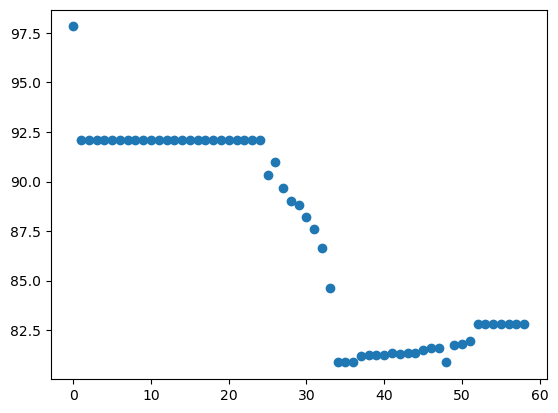

In [21]:
plt.scatter(range(len(alt)), alt)

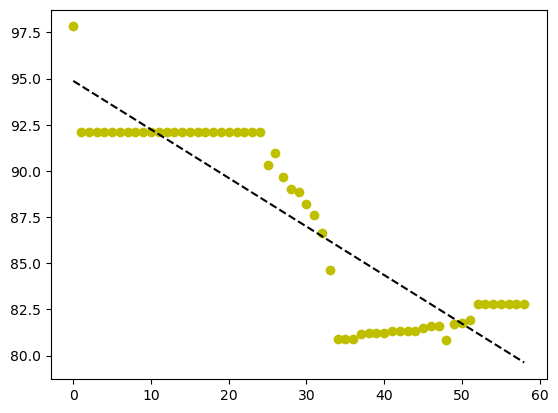

In [22]:
coef = np.polyfit(range(len(alt)), alt, 1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(range(len(alt)), alt, 'yo', range(len(alt)), poly1d_fn(range(len(alt))), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker

bestfit = poly1d_fn(range(len(alt)))

In [23]:
bestfit

array([94.87622709, 94.6133341 , 94.35044111, 94.08754812, 93.82465512,
       93.56176213, 93.29886914, 93.03597615, 92.77308316, 92.51019017,
       92.24729717, 91.98440418, 91.72151119, 91.4586182 , 91.19572521,
       90.93283222, 90.66993922, 90.40704623, 90.14415324, 89.88126025,
       89.61836726, 89.35547427, 89.09258127, 88.82968828, 88.56679529,
       88.3039023 , 88.04100931, 87.77811632, 87.51522332, 87.25233033,
       86.98943734, 86.72654435, 86.46365136, 86.20075837, 85.93786537,
       85.67497238, 85.41207939, 85.1491864 , 84.88629341, 84.62340042,
       84.36050742, 84.09761443, 83.83472144, 83.57182845, 83.30893546,
       83.04604247, 82.78314947, 82.52025648, 82.25736349, 81.9944705 ,
       81.73157751, 81.46868452, 81.20579153, 80.94289853, 80.68000554,
       80.41711255, 80.15421956, 79.89132657, 79.62843358])

In [24]:
totalmass= 0
totalh= 0 
for i in range (imaxenergy): 
    deltalatlong = np.abs(degtom(lat[i], long[i], lat[i+1], long[i+1])) #change in lat converted to meters 
    deltaalt = (np.abs(bestfit[i+1]-bestfit[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalatlong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [25]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

[5.32475496e-05 3.36882034e-05] [2.48488565e-05 1.57211616e-05] [0.00024849 0.00015721]


In [26]:
#3-period Simple Moving Average
window_size = 3
weights = np.ones(window_size) / window_size
sma_numpy = np.convolve(alt, weights, mode='valid')

print(sma_numpy)

[94.0162525  92.11309353 92.11433661 92.11479158 92.11478321 92.11399614
 92.11322168 92.11244983 92.1118336  92.1118418  92.11247205 92.11373057
 92.11514543 92.11609201 92.11593939 92.11468688 92.11264434 92.11044294
 92.10886596 92.10854397 92.10915734 92.10992505 92.11053324 91.50924319
 91.13097014 90.30980174 89.88294893 89.17027356 88.69658694 88.2188601
 87.48370427 86.27838458 84.04010619 82.12191007 80.87700268 80.98057826
 81.09479202 81.21980268 81.2319988  81.26736264 81.28818474 81.32904401
 81.33970536 81.39714924 81.47867959 81.56003344 81.35360071 81.40034725
 81.46008013 81.81682925 82.17316235 82.51228994 82.79883901 82.79997349
 82.80584593 82.81234305 82.81628205]


In [27]:
len(sma_numpy)

57

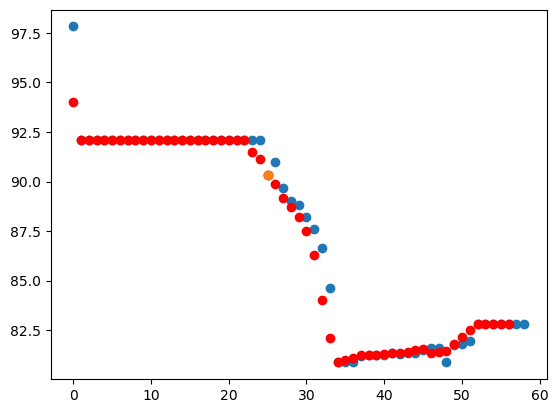

In [28]:
plt.scatter(range(len(alt)), alt)
plt.scatter(range(len(sma_numpy)), sma_numpy, c='red')# not the same size... problems in calculating size from this
plt.scatter(imaxenergy, alt[imaxenergy])

# Recipe for functions of multiple variables

Suppose we have many variables with uncertainties and some function of those variables $f(x,y,z,\ldots)$.  Then the uncertainty is:

$$\sigma_f^2 = \left(\partial f \over \partial x\right)^2 \ \sigma_x^2 +
               \left(\partial f \over \partial y\right)^2 \ \sigma_y^2 +
               \left(\partial f \over \partial z\right)^2 \ \sigma_z^2 + \ldots$$